## Task 2: Uncertainty estimation before and after calibration

#### Goal: Assess the effect of probability calibration on prediction uncertainty.

1. Evaluate ensemble accuracy before and after calibration on the test set. Compare the two using McNemar's test.
2. Compute and plot the distribution of **total uncertainty** (predictive entropy) before and after calibration:
$$H = -\sum_c \bar{p}_c \log \bar{p}_c$$
where $\bar{p}_c$ is the mean predicted probability for class $c$ across ensemble members.
3. Compute and plot the distribution of **epistemic uncertainty** (mutual information between predictions and model parameters) before and after calibration:
$$U_{\text{epistemic}} = H(\bar{p}) - \frac{1}{K}\sum_{k=1}^K H(p^{(k)})$$
4. Compute and plot the distribution of **aleatoric uncertainty** (expected entropy of individual model predictions) before and after calibration:
$$U_{\text{aleatoric}} = \frac{1}{K}\sum_{k=1}^K H(p^{(k)})$$

**Assignment:** Compare classifier accuracy and uncertainty distributions before and after probability calibration.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from utils import *

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=5000, n_features=20)
X, y = torch.tensor(X, dtype=torch.float), torch.tensor(y)

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2)

model = MLP(input_size=20, hidden_layers=[64, 256, 64], output_size=2)

fold_models = []
fold_models = fold_train(X_trainval=X_trainval, y_trainval=y_trainval,
                         model=model, EPOCHS=2, device=device)

ensemble = [load_model(k, model, device) for k in fold_models]

scalers = []
for i, m in enumerate(ensemble):
    print(f"Fitting scaler for model {i+1}/5...")
    s = fit_temperature(m, X_test, y_test)
    scalers.append(s)

Fold 1/5 — best val loss: 0.5944
Fold 2/5 — best val loss: 0.6020
Fold 3/5 — best val loss: 0.5971
Fold 4/5 — best val loss: 0.5934
Fold 5/5 — best val loss: 0.6073
Fitting scaler for model 1/5...
  Fitted T = 2.2086
Fitting scaler for model 2/5...
  Fitted T = 2.2146
Fitting scaler for model 3/5...
  Fitted T = 2.2148
Fitting scaler for model 4/5...
  Fitted T = 2.2280
Fitting scaler for model 5/5...
  Fitted T = 2.2353


In [4]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

y_true = y_test.numpy()
X_test_dev = X_test.to(device)

probs_before = get_all_probs(ensemble, X_test, device).mean(axis=0)
probs_after = get_all_probs(scalers, X_test, device).mean(axis=0)

preds_before = probs_before.argmax(axis=1)
preds_after = probs_after.argmax(axis=1)

correct_before = (preds_before == y_true)
correct_after = (preds_after == y_true)

table = np.array([
    [(~correct_before & ~correct_after).sum(), (correct_before & ~correct_after).sum()],
    [(~correct_before & correct_after).sum(), (correct_before & correct_after).sum()]
])

result = mcnemar(table, exact=False, correction=True)

acc_before = correct_before.mean()
acc_after = correct_after.mean()

off = table[0,1] + table[1,0]
if off == 0:
    stat, p = 0.0, 1.0
else:
    res = mcnemar(table, exact=False, correction=True)
    stat, p = res.statistic, res.pvalue

print(f"Accuracy before: {acc_before:.4f}")
print(f"Accuracy after: {acc_after:.4f}")
print(f"McNemar statistic: {result.statistic:.4f},  p-value: {result.pvalue:.4f}")
print(f"→ {'No significant difference in accuracy' if result.pvalue > 0.05 else 'Significant difference in accuracy (p < 0.05)'}")

Accuracy before: 0.8200
Accuracy after: 0.8200
McNemar statistic: inf,  p-value: 0.0000
→ Significant difference in accuracy (p < 0.05)


/Users/dominikmika/PycharmProjects/Deep-learning-lab/.venv/lib/python3.13/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning: divide by zero encountered in scalar divide
  statistic = (np.abs(n1 - n2) - corr)**2 / (1. * (n1 + n2))


In [5]:
total_b, epist_b, aleat_b = uncertainty_decomposition(ensemble, X_test, device)
total_a, epist_a, aleat_a = uncertainty_decomposition(scalers,  X_test, device)

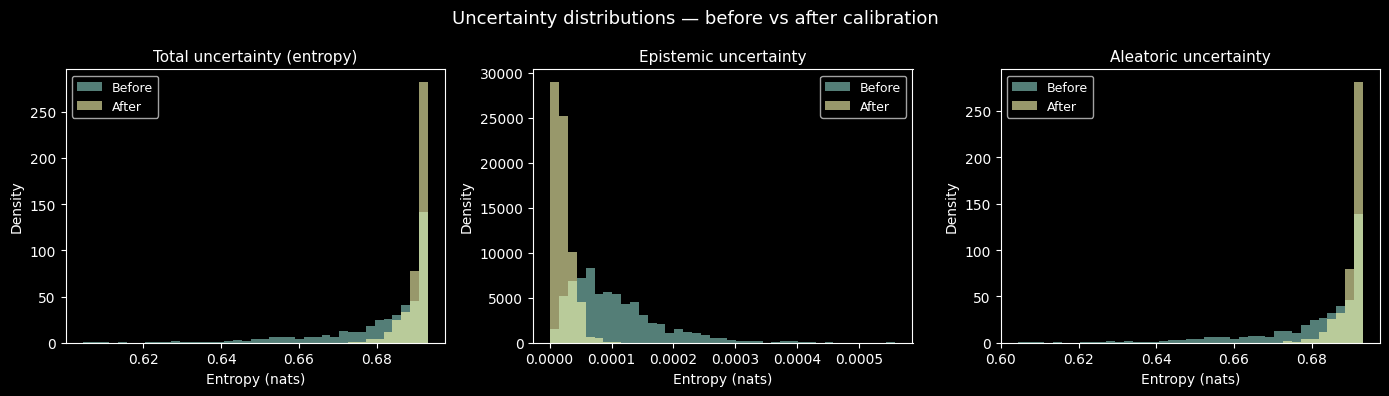

Total         before: mean=0.6812 std=0.0149   after: mean=0.6907 std=0.0032
Epistemic     before: mean=0.0001 std=0.0001   after: mean=0.0000 std=0.0000
Aleatoric     before: mean=0.6811 std=0.0149   after: mean=0.6906 std=0.0032


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Uncertainty distributions — before vs after calibration", fontsize=13)

pairs = [
    (total_b, total_a, "Total uncertainty (entropy)"),
    (epist_b, epist_a, "Epistemic uncertainty"),
    (aleat_b, aleat_a, "Aleatoric uncertainty"),
]

for ax, (before, after, title) in zip(axes, pairs):
    bins = np.linspace(
        min(before.min(), after.min()),
        max(before.max(), after.max()),
        40
    )
    ax.hist(before, bins=bins, alpha=0.6, label="Before", density=True)
    ax.hist(after, bins=bins, alpha=0.6, label="After", density=True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Entropy (nats)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

for name, before, after in [
    ("Total", total_b, total_a),
    ("Epistemic", epist_b, epist_a),
    ("Aleatoric", aleat_b, aleat_a),
]:
    print(f"{name:12s}  before: mean={before.mean():.4f} std={before.std():.4f}"
          f"   after: mean={after.mean():.4f} std={after.std():.4f}")